<h1 align="center">
  <span style="background: linear-gradient(90deg, #1507d3ff, #7873f5); 
               -webkit-background-clip: text; 
               -webkit-text-fill-color: transparent;">
    AUTOMOBILE DATASET
  </span>
</h1>


---

Preparacion de datos 

In [42]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader
from torch.utils.tensorboard import SummaryWriter  
from torch.utils.data import random_split
from torch.utils.data import Dataset

In [43]:
class StandardScaler:

    def __init__(self, mean=None, std=None, epsilon=1e-7):
        """Standard Scaler.
        The class can be used to normalize PyTorch Tensors using native functions. The module does not expect the
        tensors to be of any specific shape; as long as the features are the last dimension in the tensor, the module
        will work fine.
        :param mean: The mean of the features. The property will be set after a call to fit.
        :param std: The standard deviation of the features. The property will be set after a call to fit.
        :param epsilon: Used to avoid a Division-By-Zero exception.
        """
        self.mean = mean
        self.std = std
        self.epsilon = epsilon
    def fit(self, values):
        dims = list(range(values.dim() - 1))
        self.mean = torch.mean(values, dim=dims)
        self.std = torch.std(values, dim=dims)

    def transform(self, values):
        return (values - self.mean) / (self.std + self.epsilon)

    def fit_transform(self, values):
        self.fit(values)
        return self.transform(values)

    def __repr__(self):
        return f"mean: {self.mean}, std:{self.std}, epsilon:{self.epsilon}"

In [44]:
class AutomobileDataset(Dataset):
    def __init__(self, csv_file, root_dir='', transform=None):
        # Define the column names based on the dataset
        cols = ["symboling", "normalized-losses", "make", "fuel-type", "aspiration", "num-of-doors", "body-style", 
                "drive-wheels", "engine-location", "wheel-base", "length", "width", "height", "curb-weight",
                "engine-type", "num-of-cylinders", "engine-size", "fuel-system", "bore", "stroke",
                "compression-ratio", "horsepower", "peak-rpm", "city-mpg", "highway-mpg", "price"]       
        
        df_automobile = pd.read_csv(csv_file, na_values="?", names=cols)
        df_automobile.dropna(inplace=True)  
        
        # Convert categorical columns to numerical using one-hot encoding
        cols_categorical = ["make", "fuel-type", "aspiration", "num-of-doors", "body-style","drive-wheels", "engine-location", "engine-type", "num-of-cylinders", "fuel-system"]
        df_automobile = pd.get_dummies(df_automobile, columns=cols_categorical)

        # Separate features and target variable
        # axis = 1 means we are dropping a column, axis = 0 means we are dropping a row
        X = df_automobile.drop("price", axis=1).astype(float).values
        y = df_automobile["price"].astype(float).values

        X_tensor = torch.tensor(X, dtype=torch.float32)

        # Standardize the features
        scaler = StandardScaler()
        X_scaled = torch.tensor(scaler.fit_transform(X_tensor), dtype=torch.float32)
        
        # view(-1, 1) means we want to reshape the tensor to have one column and as many rows as needed
        y_tensor = torch.tensor(y, dtype=torch.float32).view(-1, 1)
        
        self.data = torch.cat((X_scaled, y_tensor), 1)

        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()
        
        preds = self.data[idx, :-1]  # All columns except the last one are features
        spcs = self.data[idx, -1:]   # El -1: asegura que siga siendo una mini-columna vertical
        
        sample = (preds, spcs)

        if self.transform:
            sample = self.transform(sample)
        return sample

In [45]:
dataset = AutomobileDataset(csv_file="../../docs/automobile/imports-85.data", root_dir=".")
print(f"Total samples in dataset: {len(dataset)}")
print(dataset[0])

Total samples in dataset: 159
(tensor([ 1.0596,  1.2024,  0.2972,  0.3633,  0.3042,  0.1766, -0.2576, -0.3357,
        -0.4119,  0.5549, -0.0414,  0.2006,  0.8291, -0.4136, -0.3223,  6.2053,
        -0.1601, -0.1382, -0.2294, -0.2975, -0.0793, -0.2718, -0.1796, -0.2582,
        -0.3562, -0.2139, -0.1974, -0.0793, -0.1974, -0.2848, -0.4906, -0.2294,
        -0.2718, -0.3217,  0.3217,  0.4508, -0.4508,  0.8182, -0.8182, -0.1125,
        -0.1796, -0.7350,  1.0031, -0.3449, -0.2294,  0.7149, -0.6360,  0.0000,
        -0.2294, -0.2294,  0.5393, -0.2848, -0.2294, -0.0793, -0.2139,  0.4099,
        -0.3097, -0.0793, -0.2718, -0.8075, -0.3217, -0.0793,  1.2145, -0.1796]), tensor([13950.]))


/tmp/ipykernel_24404/1183852195.py:25: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_scaled = torch.tensor(scaler.fit_transform(X_tensor), dtype=torch.float32)


In [46]:
lonxitudeDataset = len(dataset)

tamTrain = int(lonxitudeDataset * 0.8)
tamVal = lonxitudeDataset - tamTrain 

print(f"Tam dataset: {lonxitudeDataset} train: {tamTrain} val: {tamVal}")

# División de datos
train_set, val_set = random_split(dataset, [tamTrain, tamVal])

# DataLoaders
train_ldr = torch.utils.data.DataLoader(train_set, batch_size=2, shuffle=True, drop_last=False)
validation_loader = torch.utils.data.DataLoader(val_set, batch_size=4, shuffle=False, num_workers=2)

Tam dataset: 159 train: 127 val: 32


In [59]:
import torch.nn.functional as F

class Model(nn.Module):
    def __init__(self, input_dim):
        super(Model, self).__init__()
        self.layer1 = nn.Linear(input_dim, 50)
        self.layer2 = nn.Linear(50, 50)
        self.layer3 = nn.Linear(50, 1)
        
    def forward(self, x):
        x = F.relu(self.layer1(x))
        x = F.relu(self.layer2(x))
        return self.layer3(x)

In [60]:
model     = Model(65)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn   = nn.MSELoss()
display(model)

Model(
  (layer1): Linear(in_features=65, out_features=50, bias=True)
  (layer2): Linear(in_features=50, out_features=50, bias=True)
  (layer3): Linear(in_features=50, out_features=1, bias=True)
)

In [61]:
entradaProba,dest = next(iter(train_ldr))
print("Entrada:")
display(entradaProba)
print("Desexada:")
display(dest)
saida = model(entradaProba) # esta é a proba de verdade
print("Saída:")
display(saida)
loss_fn(saida, dest)

Entrada:


tensor([[-0.6168, -0.9013, -0.2446,  0.0943, -0.1065, -0.3964, -0.3551, -0.3686,
          1.1965, -2.0223, -0.2985, -0.4504, -0.6738,  0.2424, -0.0127, -0.1601,
         -0.1601, -0.1382, -0.2294, -0.2975, -0.0793, -0.2718, -0.1796, -0.2582,
         -0.3562, -0.2139, -0.1974, -0.0793, -0.1974,  3.4890, -0.4906, -0.2294,
         -0.2718, -0.3217,  0.3217,  0.4508, -0.4508,  0.8182, -0.8182, -0.1125,
         -0.1796, -0.7350, -0.9906,  2.8810, -0.2294,  0.7149, -0.6360,  0.0000,
         -0.2294, -0.2294, -1.8426,  3.4890, -0.2294, -0.0793, -0.2139,  0.4099,
         -0.3097, -0.0793, -0.2718,  1.2305, -0.3217, -0.0793, -0.8182, -0.1796],
        [ 1.0596, -1.0696, -0.8833, -1.2595, -1.0306, -0.0879, -0.7078, -0.3686,
          1.1965, -2.0223, -0.3757, -0.7434, -1.5326, -0.0856, -0.1675, -0.1601,
         -0.1601, -0.1382, -0.2294, -0.2975, -0.0793, -0.2718, -0.1796, -0.2582,
         -0.3562, -0.2139, -0.1974, -0.0793, -0.1974,  3.4890, -0.4906, -0.2294,
         -0.2718, -0.3217, 

Desexada:


tensor([[7463.],
        [7053.]])

RuntimeError: mat1 and mat2 shapes cannot be multiplied (2x64 and 65x50)

In [50]:
model = AutomobileModel(5)
optimizer = optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.MSELoss()
inputPrueba, dest = next(iter(train_loader))
print(f"Input shape: {inputPrueba.shape}, Target shape: {dest.shape}")
display(model)


Input shape: torch.Size([32, 64]), Target shape: torch.Size([32, 1])


AutomobileModel(
  (fc1): Linear(in_features=5, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=1, bias=True)
)

In [51]:
def train_one_epoch(model, train_loader, optimizer, loss_fn):
    model.train()
    last_loss = 0.0
    # usamos enumerate para saber en que batch imos
    for i, data in enumerate(train_loader):
        # Every data instance is an input + label pair
        inputs, labels = data
        # Zero your gradients for every batch!
        optimizer.zero_grad()
        # Make predictions for this batch
        outputs = model(inputs)
        # Compute the loss and its gradients
        loss = loss_fn(outputs, labels)
        loss.backward()
        # Adjust learning weights
        optimizer.step()
        # Gather data and report
        running_loss += loss.item()
        if i % 10 == 9:
            last_loss = running_loss / 10 # loss per batch
            print('  batch {} loss: {}'.format(i + 1, last_loss))
            running_loss = 0.
    return last_loss

In [52]:
from torchmetrics import MeanSquaredError, MeanAbsoluteError, R2Score

EPOCHS = 100
loss_list     = torch.zeros((EPOCHS,))
accuracy_list = torch.zeros((EPOCHS,))

mean_squared_error = MeanSquaredError()
mean_absolute_error = MeanAbsoluteError()
r2Score = R2Score()

for epoch in range(EPOCHS):
    print('EPOCH {}:'.format(epoch + 1))

    # Poñemos o modelo en modo entrenamento
    model.train(True)
    avg_loss = train_one_epoch(epoch, writer)
    loss_list[epoch] = avg_loss
    model.train(False)
    with torch.no_grad():
        for entradas, saidas in validation_loader:
            voutputs = model(entradas).flatten()
            mean_squared_error.update(voutputs,saidas.flatten())
            mean_absolute_error.update(voutputs,saidas.flatten())
            r2Score.update(voutputs,saidas.flatten())
errorMedio = mean_squared_error.compute()
errorAbsolute =mean_absolute_error.compute()
r2 = r2Score.compute()
print(f"MSE: {errorMedio}")
print(f"MAE: {errorAbsolute}")
print(f"R^2: {r2}")


EPOCH 1:


TypeError: train_one_epoch() missing 2 required positional arguments: 'optimizer' and 'loss_fn'

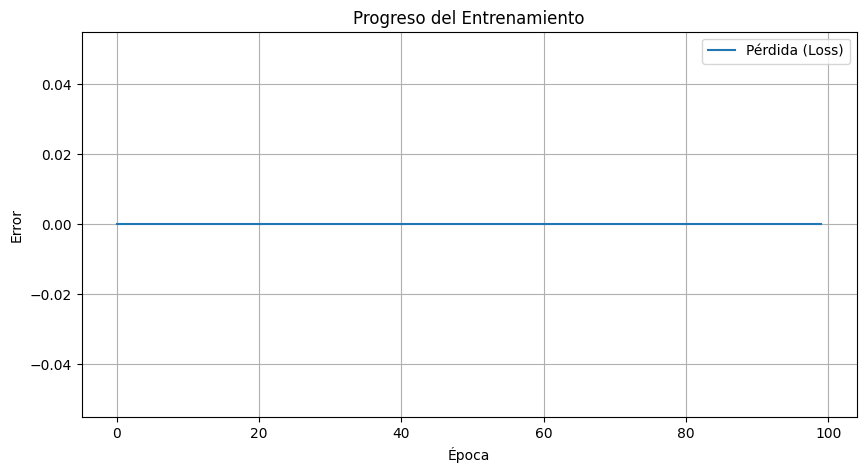

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(loss_list.detach().numpy(), label='Pérdida (Loss)')
plt.title('Progreso del Entrenamiento')
plt.xlabel('Época')
plt.ylabel('Error')
plt.legend()
plt.grid(True)
plt.show()